In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

#Load in the data
data_url = '../spambase_data/spambase.data'
names_url = '../spambase_data/spambase.names'

# parse the feature names from the .names file
feature_names = []
with open(names_url, "r") as f:
    for line in f:
        line = line.strip()
        if ':' in line and not line.startswith("|"):
            feature_names.append(line.split(":")[0].strip())
feature_names.append("label") # last column is the class label

df = pd.read_csv(data_url, header=None, names=feature_names)
x = df.drop("label", axis=1).values
y = df["label"].values

# Create the train test split for the data
x_tr, x_te, y_tr, y_te = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y 
)

print(f"Train size: {x_tr.shape[0]}   |   Test size: {x_te.shape[0]}")
print(f"Spam prevalence - train: {y_tr.mean():.3f}  test: {y_te.mean():.3f}\n")

# Part 1 Train AdaBoost for T in {10, 50, 100, 500}
T_values = [10, 50, 100, 500]
ada_results = {}

print(f"{'='*65}")
print(f"    Part 1 - AdaBoost Metrics by number of base classifiers")
print(f"{'='*65}")
print(f"    {'T':<6} {'Split':<8} {'Accuracy':>10} {'F1':>10} {'AUC':>10}")
print(f"    {'-'*46}")

for T in T_values:
    # Decision stum (max_depth=1) is the classic AdaBoost base learner
    base = DecisionTreeClassifier(max_depth=1)
    ada = AdaBoostClassifier(estimator=base, n_estimators=T, random_state=42)
    ada.fit(x_tr, y_tr)
    ada_results[T] = {"model": ada, "train": {}, "test": {}}

    for split, Xs, ys in [("train", x_tr, y_tr), ("test", x_te, y_te)]:
        y_pred = ada.predict(Xs)
        y_prob = ada.predict_proba(Xs)[:, 1]
        acc = accuracy_score(ys, y_pred)
        f1 = f1_score(ys, y_pred)
        auc = roc_auc_score(ys, y_prob)
        ada_results[T][split] = dict(accuracy=acc, f1=f1, auc=auc)
        print(f"    {T:<6} {split:<8} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f}")
    print()

# Part 2 side by side comparison: AdaBoos vs Random Forest
print(f"{'='*75}")
print(f"    Part 2 - AdaBoost vs Random Forest")
print(f"{'='*75}")
print(f"  {'T':<6} {'Model':<15} {'Accuracy':>10} {'F1':>10} {'AUC':>10}")
print(f"  {'-'*54}")

# code used to train the random forest from problem 2 for comparison
results = {}

for T in T_values:
    rf = RandomForestClassifier(n_estimators=T, random_state=42, n_jobs=1) 
    rf.fit(x_tr, y_tr)
    results[T] = {"Model": rf, "train" : {}, "test": {}}

    for split, Xs, ys in [("train", x_tr, y_tr), ("test", x_te, y_te)]:
        y_pred = rf.predict(Xs)
        y_prob = rf.predict_proba(Xs)[:, 1]
        acc = accuracy_score(ys, y_pred)
        f1 = f1_score(ys, y_pred)
        auc = roc_auc_score(ys, y_prob)
        results[T][split] = dict(accuracy=acc, f1=f1, auc=auc) 

for T in T_values:
    for label, res in [("AdaBoost", ada_results), ("RandomForest", results)]:
        r = res[T]["test"]
        print(f"  {T:<6} {label:<15} {r['accuracy']:>10.4f} {r['f1']:>10.4f} {r['auc']:>10.4f}")
    print()

Train size: 3450   |   Test size: 1151
Spam prevalence - train: 0.394  test: 0.394

    Part 1 - AdaBoost Metrics by number of base classifiers
    T      Split      Accuracy         F1        AUC
    ----------------------------------------------
    10     train        0.9058     0.8807     0.9638
    10     test         0.8914     0.8616     0.9545

    50     train        0.9348     0.9156     0.9814
    50     test         0.9209     0.8976     0.9762

    100    train        0.9414     0.9247     0.9843
    100    test         0.9314     0.9117     0.9789

    500    train        0.9522     0.9387     0.9902
    500    test         0.9374     0.9195     0.9828

    Part 2 - AdaBoost vs Random Forest
  T      Model             Accuracy         F1        AUC
  ------------------------------------------------------
  10     AdaBoost            0.8914     0.8616     0.9545
  10     RandomForest        0.9418     0.9241     0.9772

  50     AdaBoost            0.9209     0.8976     0.

# Observations for part 2
- Random Forest outperforms AdaBoost across every T value and metric
- The F1 gap is the most significant
- Random Forest converges much faster than AdaBoost
- AdaBoost has smaller train vs test gaps showing less overfitting than its counterpart

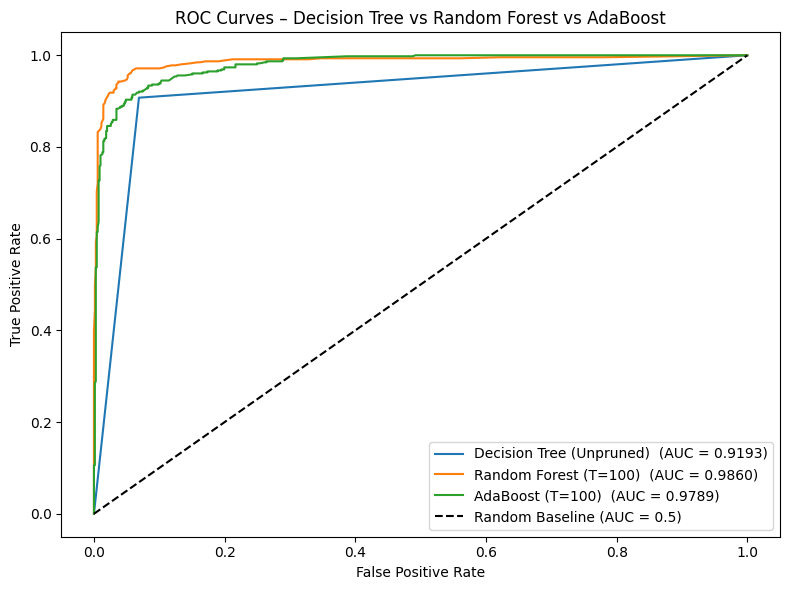

Plot saved to roc_curves.png


In [16]:
# Part 3 ROC curves
# Models: unpruned decision tree (entropy), RF T=100, AdaBoost T=100
dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_entropy.fit(x_tr, y_tr)
models = {
    "Decision Tree (Unpruned)": dt_entropy,      # from Problem 1
    "Random Forest (T=100)":    results[100]["Model"],
    "AdaBoost (T=100)":         ada_results[100]["model"]
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(x_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc = roc_auc_score(y_te, y_prob)
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.4f})")

# Random baseline
plt.plot([0, 1], [0, 1], "k--", label="Random Baseline (AUC = 0.5)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Decision Tree vs Random Forest vs AdaBoost")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()
print("Plot saved to roc_curves.png")